In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!ls "/content/drive/MyDrive/EEG Dataset"

folder_path = "/content/drive/MyDrive/EEG Dataset"

import os

for file_name in os.listdir(folder_path):
    print(file_name)


Mounted at /content/drive
F				   N  Processed				    S
Models_Hybrid_CNN_LSTM_BiLSTM_DNN  O  Processed_Hybrid_CNN_LSTM_BiLSTM_DNN  Z
F
N
O
S
Z
Processed_Hybrid_CNN_LSTM_BiLSTM_DNN
Models_Hybrid_CNN_LSTM_BiLSTM_DNN
Processed


In [ ]:
import os
import numpy as np
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

def load_eeg_txt_data(base_path):
    labels = ['F', 'N', 'O', 'S', 'Z']
    X = []
    y = []

    # Loop through each label (folder)
    for label in labels:
        folder_path = os.path.join(base_path, label)

        # Check if the folder exists
        if not os.path.exists(folder_path):
            print(f"❌ Folder {folder_path} does not exist.")
            continue
        else:
            files = os.listdir(folder_path)
            print(f"Files in '{label}' folder: {files}")

        # Check if .txt files exist and load them
        files = [f for f in files if f.lower().endswith('.txt')]  # case-insensitive check
        if not files:
            print(f"⚠️ No .txt files found in {folder_path}")
            continue

        print(f"📂 Reading {len(files)} files from {label} folder...")
        for file in files:
            file_path = os.path.join(folder_path, file)
            try:
                # Adjust delimiter if needed: ',' or '\t' or ' ' depending on file structure
                data = np.loadtxt(file_path, delimiter=None)  # try auto-split
                data = data.reshape(-1, 4097, 1)  # Reshape to match model input
                X.append(data)
                y.append(label)
            except Exception as e:
                print(f"❌ Failed to load {file_path}: {e}")

    X = np.array(X, dtype=object)
    y = np.array(y)

    print(f"\n✅ Loaded {len(X)} samples.")
    return X, y


# Usage
data_dir = "/content/drive/MyDrive/EEG Dataset"
X, y = load_eeg_txt_data(data_dir)

# Reshape the data to (500, 4097, 1)
X = X.reshape(-1, 4097, 1)  # Flatten batch dimension

# Check if all data samples are the same shape
if all(isinstance(x, np.ndarray) and x.shape == X[0].shape for x in X):
    X = np.stack(X)  # Stack the data into a proper 3D array
    print(f"🧠 EEG data shape: {X.shape}")
else:
    print("⚠️ EEG data samples have inconsistent shapes; consider padding or resizing.")

# Convert labels to one-hot encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_onehot = to_categorical(y_encoded)

print(f"🔖 Encoded labels: {le.classes_}")


Files in 'F' folder: ['F001.txt', 'F002.txt', 'F003.txt', 'F004.txt', 'F005.txt', 'F006.txt', 'F007.txt', 'F008.txt', 'F009.txt', 'F010.txt', 'F011.txt', 'F012.txt', 'F013.txt', 'F014.txt', 'F015.txt', 'F016.txt', 'F017.txt', 'F018.txt', 'F019.txt', 'F020.txt', 'F021.txt', 'F022.txt', 'F023.txt', 'F024.txt', 'F025.txt', 'F026.txt', 'F027.txt', 'F028.txt', 'F029.txt', 'F030.txt', 'F031.txt', 'F032.txt', 'F033.txt', 'F034.txt', 'F035.txt', 'F036.txt', 'F037.txt', 'F038.txt', 'F039.txt', 'F040.txt', 'F041.txt', 'F042.txt', 'F043.txt', 'F044.txt', 'F045.txt', 'F046.txt', 'F047.txt', 'F048.txt', 'F049.txt', 'F050.txt', 'F051.txt', 'F052.txt', 'F053.txt', 'F054.txt', 'F055.txt', 'F056.txt', 'F057.txt', 'F058.txt', 'F059.txt', 'F060.txt', 'F061.txt', 'F062.txt', 'F063.txt', 'F064.txt', 'F065.txt', 'F066.txt', 'F067.txt', 'F068.txt', 'F069.txt', 'F070.txt', 'F071.txt', 'F072.txt', 'F073.txt', 'F074.txt', 'F075.txt', 'F076.txt', 'F077.txt', 'F078.txt', 'F079.txt', 'F080.txt', 'F081.txt', 'F082.

In [ ]:
!pip install shap
import shap
import tensorflow as tf
!pip install --upgrade shap tensorflow


In [ ]:
import os
import shap
from tensorflow.keras.models import load_model

# Define your model path (adjust if needed)
model_path = "/content/drive/MyDrive/EEG Dataset/Models_Hybrid_CNN_LSTM_BiLSTM_DNN"
model_file = os.path.join(model_path, "hybrid_cnn_lstm_bilstm_dnn_2.h5")

# Load model
if os.path.exists(model_file):
    print("✅ Model found. Loading...")
    model = load_model(model_file)
    print("✅ Model loaded successfully.")
else:
    print(f"❌ Model file not found at: {model_file}")

# Assume X is already loaded and has shape (500, 4097, 1)
print("Shape of X:", X.shape)

# Set up SHAP
background_data = X[:100]  # (100, 4097, 1)
explainer = shap.GradientExplainer(model, background_data)

# Choose one sample
test_sample = X[123:124]  # (1, 4097, 1)
shap_values = explainer.shap_values(test_sample)


✅ Model found. Loading...


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_8
Received: inputs=['Tensor(shape=(1, 4097, 1))']
  warnings.warn(msg)


✅ Model loaded successfully.
Shape of X: (500, 4097, 1)


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_8
Received: inputs=['Tensor(shape=(50, 4097, 1))']
  warnings.warn(msg)


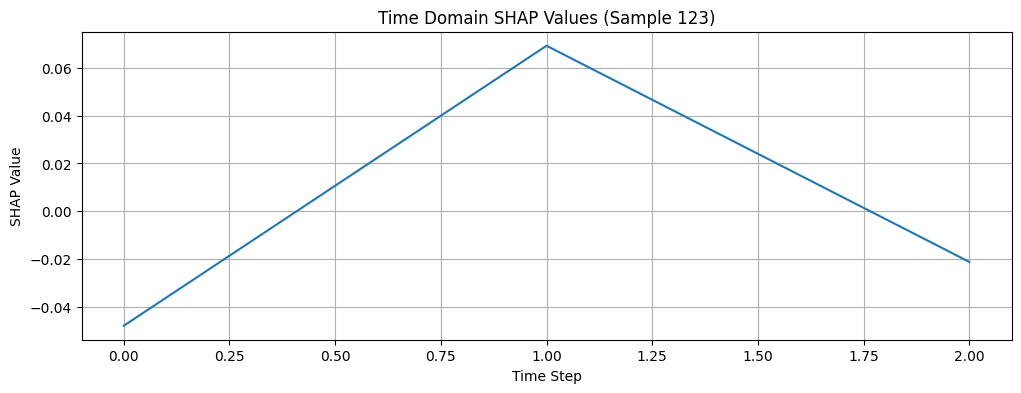

In [ ]:
import matplotlib.pyplot as plt

# Plot SHAP values over time steps for class 0 (or adjust index as needed)
plt.figure(figsize=(12, 4))
plt.plot(shap_values[0][0].squeeze())  # shap_values[0] = class 0, [0] = sample index
plt.title("Time Domain SHAP Values (Sample 123)")
plt.xlabel("Time Step")
plt.ylabel("SHAP Value")
plt.grid(True)
plt.show()


In [ ]:
print(f"SHAP values type: {type(shap_values)}")
print(f"SHAP values length: {len(shap_values)}")
print(f"SHAP values[0] shape: {shap_values[0].shape}")


SHAP values type: <class 'numpy.ndarray'>
SHAP values length: 1
SHAP values[0] shape: (4097, 1, 3)


eeg_signal shape: (4097,)


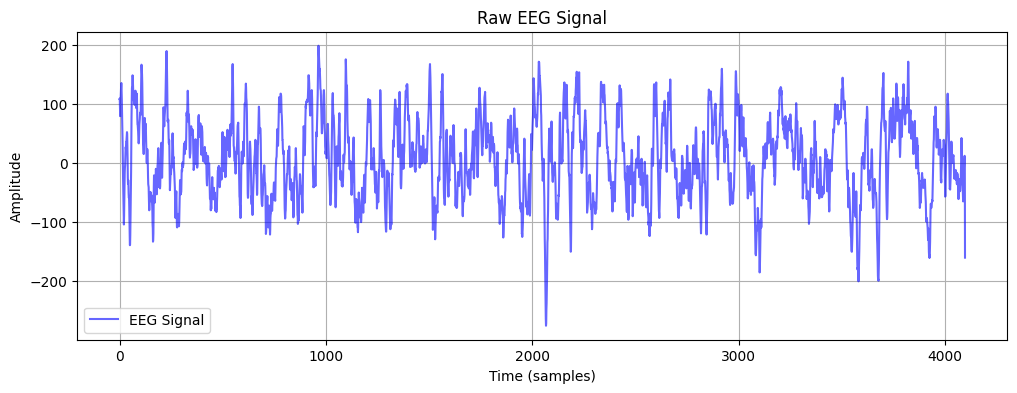

In [ ]:
import matplotlib.pyplot as plt

# Extract the signal from test_sample
eeg_signal = test_sample[0, :, 0]  # Shape: (4097,)
print("eeg_signal shape:", eeg_signal.shape)


import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(eeg_signal, label='EEG Signal', color='blue', alpha=0.6)
plt.title("Raw EEG Signal")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()



EEG signal shape: (4097,)
EEG signal min/max: -64.0 / 123.0
First 10 EEG values: [34. 33. 28. 22. 21. 22. 22. 19. 22. 18.]


<ipython-input-7-c26d3cd37789>:34: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


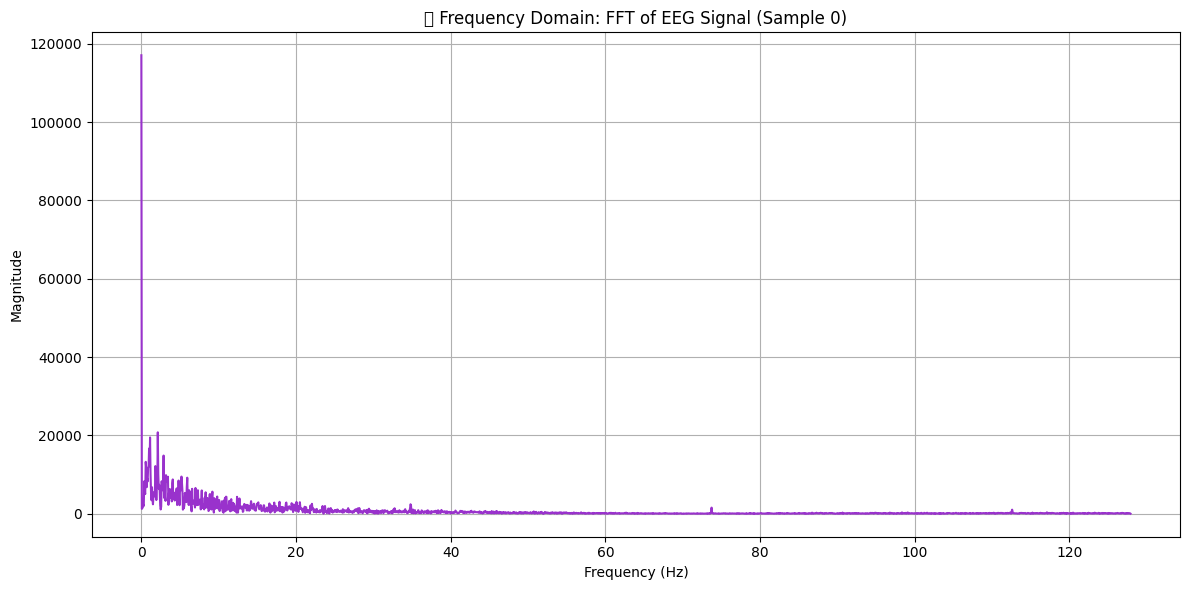

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- CONFIG ---
sample_idx = 0          # Index of the EEG sample to visualize
channel = 0             # Assuming mono-channel EEG
sampling_rate = 256     # Hz - adjust to your dataset's rate

# --- EXTRACT EEG SIGNAL ---
eeg_signal = X[sample_idx, :, channel]  # Should be shape (4097,)
eeg_signal = np.array(eeg_signal).astype(np.float32)  # Ensure proper numeric dtype

# --- DEBUG INFO ---
print(f"EEG signal shape: {eeg_signal.shape}")
print(f"EEG signal min/max: {eeg_signal.min()} / {eeg_signal.max()}")
print(f"First 10 EEG values: {eeg_signal[:10]}")

# --- APPLY FFT ---
n_samples = len(eeg_signal)
fft_result = np.fft.fft(eeg_signal)
freqs = np.fft.fftfreq(n_samples, d=1/sampling_rate)

# --- POSITIVE FREQUENCY COMPONENTS ---
fft_magnitude = np.abs(fft_result[:n_samples // 2])
freqs = freqs[:n_samples // 2]

# --- PLOT ---
plt.figure(figsize=(12, 6))
plt.plot(freqs, fft_magnitude, color='darkorchid')
plt.title(f'🧠 Frequency Domain: FFT of EEG Signal (Sample {sample_idx})')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Try these to inspect which variable is your EEG input
for var_name in dir():
    if not var_name.startswith("_") and isinstance(eval(var_name), (np.ndarray, list)):
        try:
            print(f"{var_name}: shape = {np.array(eval(var_name)).shape}")
        except:
            pass


In: shape = (60,)
X: shape = (500, 4097, 1)
X_input: shape = (1, 4097, 1)
background_data: shape = (100, 4097, 1)
class_labels: shape = (5,)
eeg_signal: shape = (4097,)
fft_eeg: shape = (2048,)
fft_magnitude: shape = (2048,)
fft_magnitude_masked: shape = (961,)
fft_result: shape = (4097,)
fft_shap: shape = (2048,)
files: shape = (0,)
freqs: shape = (2048,)
freqs_masked: shape = (961,)
idx: shape = (1120,)
mask: shape = (4097,)
norm_shap: shape = (4096,)
points: shape = (4097, 1, 2)
pred: shape = (1, 3)
processed_files: shape = (5,)
segments: shape = (4096, 2, 2)
shap_class_values: shape = (4097,)
shap_norm: shape = (4097,)
shap_overlay: shape = (4097,)
shap_scaled: shape = (4097,)
shap_signal: shape = (4097,)
shap_values: shape = (1, 4097, 1, 3)
subdirs: shape = (8,)
test_sample: shape = (1, 4097, 1)
x: shape = (4097,)
y: shape = (500,)
y_encoded: shape = (500,)
y_onehot: shape = (500, 5)


EEG signal shape: (4097,)
EEG signal min/max: -64.0 / 123.0
First 10 EEG values: [34. 33. 28. 22. 21. 22. 22. 19. 22. 18.]


<ipython-input-61-96e87c1b0c31>:38: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


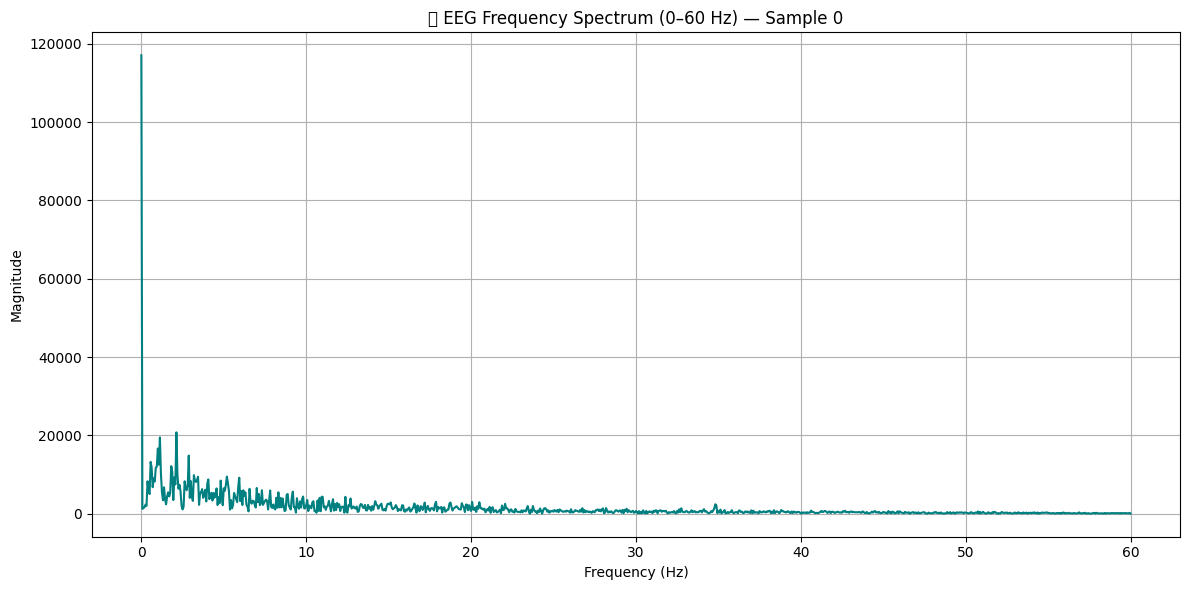

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- CONFIG ---
sample_idx = 0
channel = 0
sampling_rate = 256  # Hz

# --- EXTRACT EEG SIGNAL ---
eeg_signal = X[sample_idx, :, channel]
eeg_signal = np.array(eeg_signal).astype(np.float32)  # Ensure correct dtype

print(f"EEG signal shape: {eeg_signal.shape}")
print(f"EEG signal min/max: {eeg_signal.min()} / {eeg_signal.max()}")
print(f"First 10 EEG values: {eeg_signal[:10]}")

# --- APPLY FFT ---
n_samples = len(eeg_signal)
fft_result = np.fft.fft(eeg_signal)
freqs = np.fft.fftfreq(n_samples, d=1/sampling_rate)

fft_magnitude = np.abs(fft_result[:n_samples // 2])
freqs = freqs[:n_samples // 2]

# --- MASK FOR EEG FREQUENCIES ONLY ---
max_freq = 60  # Focus up to 60Hz (Gamma range)
mask = freqs <= max_freq
freqs_masked = freqs[mask]
fft_magnitude_masked = fft_magnitude[mask]

# --- PLOT ---
plt.figure(figsize=(12, 6))
plt.plot(freqs_masked, fft_magnitude_masked, color='teal')
plt.title(f'🧠 EEG Frequency Spectrum (0–{max_freq} Hz) — Sample {sample_idx}')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid(True)
plt.tight_layout()
plt.show()


<ipython-input-62-6ebb8f1ba63f>:58: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


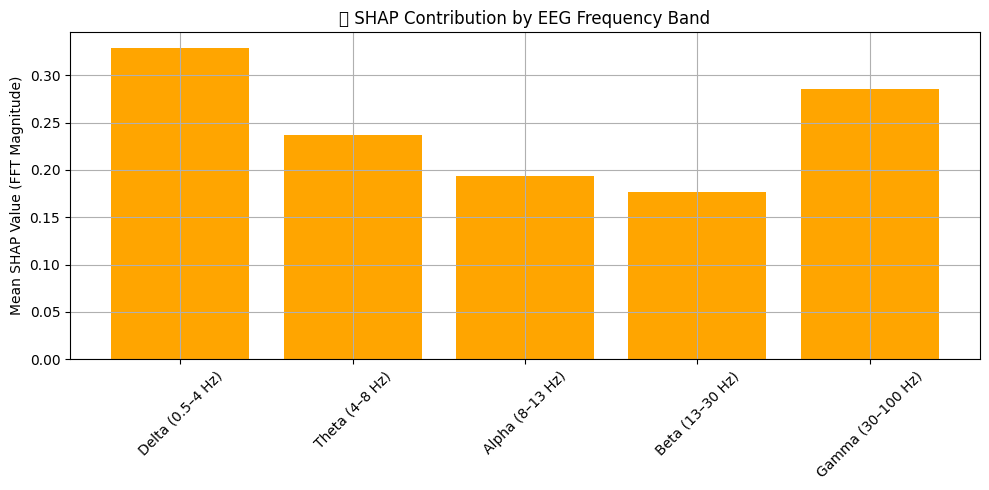

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- CONFIG ---
sample_idx = 0
channel = 0
sampling_rate = 256

# --- STEP 0: Select EEG sample ---
eeg_signal = X[sample_idx, :, channel]
eeg_signal = np.array(eeg_signal).astype(np.float32)

# --- STEP 1: Get SHAP values for predicted class ---
# Convert input properly for model
X_input = np.array(X[sample_idx:sample_idx+1]).astype(np.float32)

# Predict if needed
if 'pred' not in locals():
    pred = model.predict(X_input)

# Get SHAP values for predicted class
shap_signal = shap_values[0, :, 0, pred.argmax()]


# --- STEP 2: FFT of both EEG and SHAP signal ---
n_samples = eeg_signal.shape[0]
freqs = np.fft.fftfreq(n_samples, d=1/sampling_rate)
mask = freqs > 0  # Exclude 0 Hz

fft_eeg = np.abs(np.fft.fft(eeg_signal))[mask]
fft_shap = np.abs(np.fft.fft(shap_signal))[mask]
freqs = freqs[mask]

# --- STEP 3: Define Frequency Bands ---
bands = {
    "Delta (0.5–4 Hz)": (0.5, 4),
    "Theta (4–8 Hz)": (4, 8),
    "Alpha (8–13 Hz)": (8, 13),
    "Beta (13–30 Hz)": (13, 30),
    "Gamma (30–100 Hz)": (30, 100)
}

band_power = {}
band_shap = {}

for band, (low, high) in bands.items():
    idx = np.where((freqs >= low) & (freqs <= high))[0]
    band_power[band] = np.mean(fft_eeg[idx]) if len(idx) else 0
    band_shap[band] = np.mean(fft_shap[idx]) if len(idx) else 0

# --- STEP 4: Plot SHAP Contributions ---
plt.figure(figsize=(10, 5))
plt.bar(band_shap.keys(), band_shap.values(), color='orange')
plt.title("📊 SHAP Contribution by EEG Frequency Band")
plt.ylabel("Mean SHAP Value (FFT Magnitude)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


<ipython-input-63-46d0474929a0>:40: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


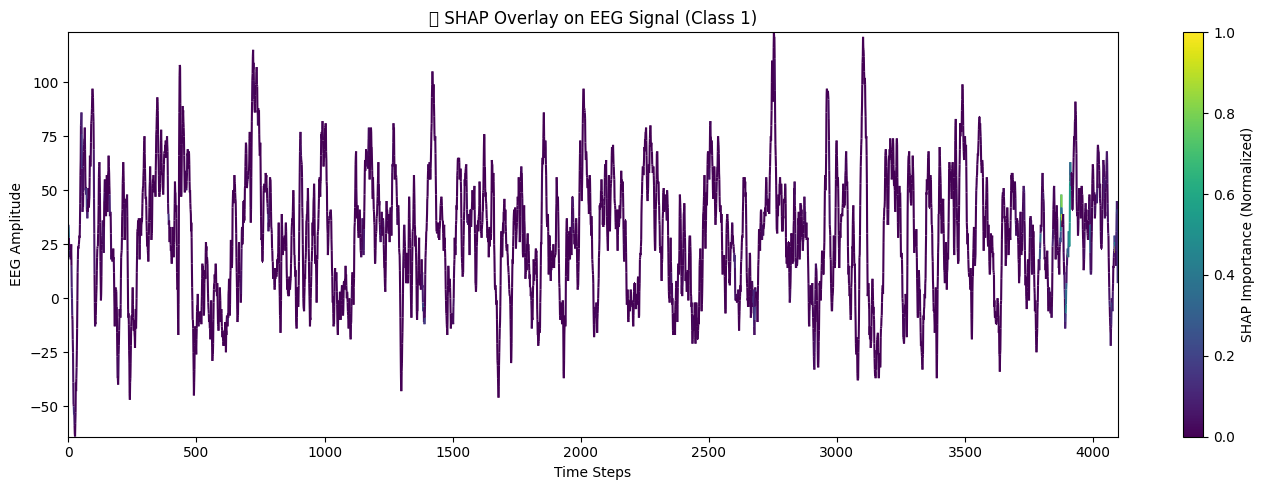

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from sklearn.preprocessing import MinMaxScaler

# --- Parameters ---
sample_idx = 0  # EEG sample to visualize
predicted_class_idx = 1  # SHAP class index to visualize

# --- Extract SHAP values ---
shap_signal = shap_values[sample_idx, :, 0, predicted_class_idx]  # shape: (4097,)

# --- Normalize SHAP values for color intensity ---
scaler = MinMaxScaler()
shap_scaled = scaler.fit_transform(np.abs(shap_signal).reshape(-1, 1)).flatten()

# --- Get EEG signal ---
eeg_signal = X[sample_idx, :, 0]  # shape: (4097,)

# --- Prepare colored segments for line plot ---
x = np.arange(len(eeg_signal))
points = np.array([x, eeg_signal]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# Use SHAP values as segment colors
norm_shap = shap_scaled[:-1]
lc = LineCollection(segments, cmap='viridis', linewidth=1.5)
lc.set_array(norm_shap)

# --- Plot ---
plt.figure(figsize=(14, 5))
plt.gca().add_collection(lc)
plt.xlim(x.min(), x.max())
plt.ylim(eeg_signal.min() - 0.1, eeg_signal.max() + 0.1)
cbar = plt.colorbar(lc)
cbar.set_label('SHAP Importance (Normalized)')
plt.title(f"📈 SHAP Overlay on EEG Signal (Class {predicted_class_idx})")
plt.xlabel("Time Steps")
plt.ylabel("EEG Amplitude")
plt.tight_layout()
plt.show()


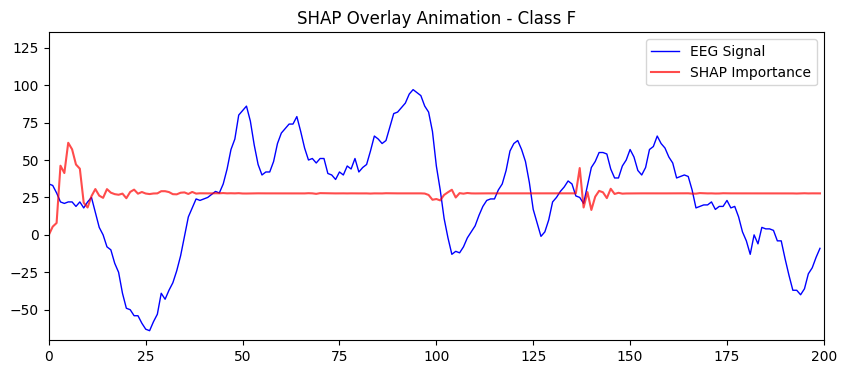

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

# Define class labels
class_labels = ['F', 'N', 'S', 'Z', 'O']

# Select SHAP for a specific class (e.g., 'F' class)
class_idx = 0
shap_class_values = shap_values[0].squeeze()[:, class_idx]  # shape: (4097,)

# Normalize and overlay
shap_norm = (shap_class_values - shap_class_values.min()) / (shap_class_values.max() - shap_class_values.min())
shap_overlay = shap_norm * eeg_signal.max() * 0.5

# Plot setup
fig, ax = plt.subplots(figsize=(10, 4))
line_signal, = ax.plot([], [], label='EEG Signal', color='blue', linewidth=1)
line_shap, = ax.plot([], [], label='SHAP Importance', color='red', alpha=0.7)
ax.set_xlim(0, 200)
ax.set_ylim(eeg_signal.min()*1.1, eeg_signal.max()*1.1)
ax.set_title(f"SHAP Overlay Animation - Class {class_labels[class_idx]}")
ax.legend()

# Animation update function
def update(frame):
    window = 200
    start = frame
    end = frame + window

    if end > len(eeg_signal):
        return line_signal, line_shap

    x = np.arange(start, end)
    y_signal = eeg_signal[start:end]
    y_shap = shap_overlay[start:end]

    line_signal.set_data(x, y_signal)
    line_shap.set_data(x, y_shap)

    ax.set_xlim(start, end)
    return line_signal, line_shap

ani = animation.FuncAnimation(fig, update, frames=np.arange(0, len(eeg_signal) - 200, 10), interval=40, blit=True)
plt.show()


In [ ]:
# Install SHAP if not already installed
!pip install shap

# --- Imports ---
import os
import shap
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import load_model


✅ EEG data shape: X= (500, 1000, 1)  y= (500,)
✅ Truncated EEG shape: (500, 1000, 1)


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_1260
Received: inputs=['Tensor(shape=(3, 1000, 1))']
  warnings.warn(msg)
/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_1260
Received: inputs=['Tensor(shape=(50, 1000, 1))']
  warnings.warn(msg)


Shape of shap_values: (3, 1000, 1, 1)


<ipython-input-83-14d437734296>:39: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values.reshape(3, -1), test_samples.reshape(3, -1))


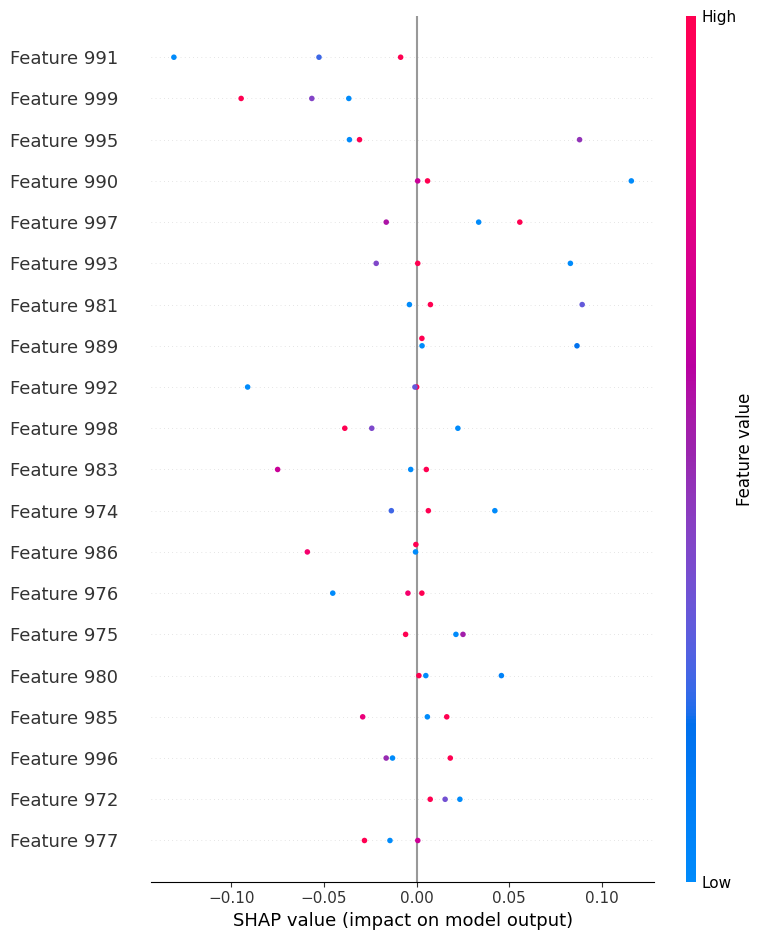

In [ ]:
# --- Load and preprocess EEG data ---
# Assume original shape is (500, 4097, 1)
print("✅ EEG data shape: X=", X.shape, " y=", y.shape)

# Truncate to reduce memory (e.g., first 1000 time steps)
X = X[:, :1000, :]  # Changed to slice along the second axis
print("✅ Truncated EEG shape:", X.shape)

# --- Ensure correct data types ---
X = X.astype(np.float32)  # Ensure input data is float32

# --- Encode string labels to numerical using LabelEncoder ---
# Assuming 'le' and 'LabelEncoder' are already defined
y = le.fit_transform(y)  # Convert string labels to numerical
y = y.astype(np.int32)    # Now convert to int32

# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# --- Save model (optional) ---
# model.save("eeg_small_model.h5")

# --- Load model if needed ---
# model = load_model("eeg_small_model.h5")

# --- Prepare SHAP explainer ---
background = X_train[:10].astype(np.float32)       # shape: (10, 1000, 1)
test_samples = X_test[:3].astype(np.float32)       # shape: (3, 1000, 1)

explainer = shap.GradientExplainer(model, background)
shap_values = explainer.shap_values(test_samples)

print("Shape of shap_values:", np.shape(shap_values))

# Optional safety check
if isinstance(shap_values, list):
    shap_values = shap_values[0]

# Flatten test samples for SHAP summary plot
shap.summary_plot(shap_values.reshape(3, -1), test_samples.reshape(3, -1))


In [ ]:
pip install lime


157/157 ━━━━━━━━━━━━━━━━━━━━ 103s 656ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
✅ Prediction probabilities:
0.00 -> Class 0 (0)
0.02 -> Class 1 (1)
0.98 -> Class 2 (2)


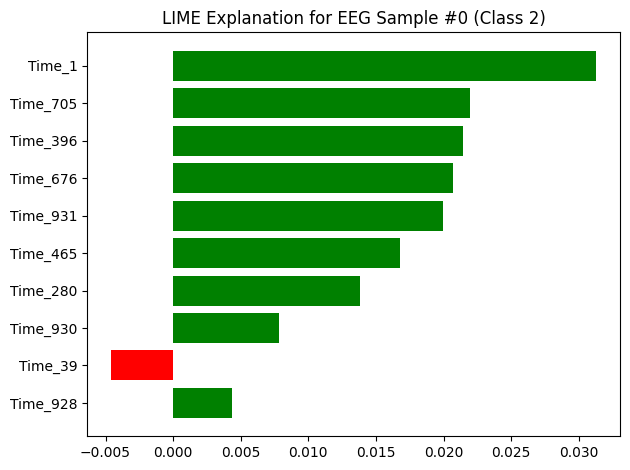

In [ ]:

# --- Prepare LIME Explainer ---
# Flatten the 3D data to 2D (samples, time steps)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# LIME expects 2D input, so generate feature names for time steps
feature_names = [f"Time_{i}" for i in range(X_train_flat.shape[1])]

explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_train_flat,
    feature_names=feature_names,
    class_names=le.classes_.tolist(),  # Use actual label names
    mode='classification',
    discretize_continuous=False
)

# --- Prediction function wrapper for LIME ---
def predict_fn(input_2d):
    input_3d = input_2d.reshape((input_2d.shape[0], input_2d.shape[1], 1))  # back to 3D
    return model.predict(input_3d)

# --- Pick a test sample (same as SHAP test_samples[0]) ---
sample_index = 0
test_sample = X_test_flat[sample_index]

# --- Generate LIME explanation ---
explanation = explainer.explain_instance(
    data_row=test_sample,
    predict_fn=predict_fn,
    num_features=10,
    top_labels=1
)

# --- Display in notebook ---
explanation.show_in_notebook(show_table=True)

# --- Get predicted class and plot bar chart ---
pred_probs = predict_fn(test_sample.reshape(1, -1))
predicted_class = np.argmax(pred_probs)

# Optional: print class prediction details
print("✅ Prediction probabilities:")
for i, prob in enumerate(pred_probs[0]):
    print(f"{prob:.2f} -> Class {i} ({le.inverse_transform([i])[0]})")

# ✅ Fixed: Bar plot for predicted class
fig = explanation.as_pyplot_figure(label=predicted_class)
plt.title(f"LIME Explanation for EEG Sample #{sample_index} (Class {predicted_class})")
plt.tight_layout()
plt.show()
